## Comparación de Kernels SVM con el Dataset Iris

En esta sección compararemos diferentes kernels de SVM aplicados al dataset Iris para clasificar las especies de flores. Evaluaremos el rendimiento usando matrices de confusión y reportes de clasificación.

In [ ]:
# Importaciones necesarias para la comparación de kernels
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Crear un DataFrame para facilitar la visualización
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = [iris.target_names[i] for i in y]

print("Dataset Iris:")
print(f"Forma de X: {X.shape}")
print(f"Clases: {iris.target_names}")
print(f"Número de muestras por clase: {pd.Series(y).value_counts().sort_index().tolist()}")
print("\nPrimeras 5 filas del dataset:")
print(iris_df.head())

Dataset Iris:
Forma de X: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']
Número de muestras por clase: [50, 50, 50]

Primeras 5 filas del dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [3]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("División de los datos:")
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

División de los datos:
Entrenamiento: 105 muestras
Prueba: 45 muestras


In [4]:
# Definir los kernels a comparar
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Diccionario para almacenar los resultados
results = {}

print("Entrenando modelos SVM con diferentes kernels...\n")

for kernel in kernels:
    print(f"🔄 Entrenando SVM con kernel '{kernel}'...")
    
    # Crear y entrenar el modelo
    if kernel == 'poly':
        # Para el kernel polinomial, especificamos el grado
        svm_model = SVC(kernel=kernel, degree=3, random_state=42)
    else:
        svm_model = SVC(kernel=kernel, random_state=42)
    
    # Entrenar el modelo
    svm_model.fit(X_train, y_train)
    
    # Realizar predicciones
    y_pred = svm_model.predict(X_test)
    
    # Calcular accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Almacenar resultados
    results[kernel] = {
        'model': svm_model,
        'predictions': y_pred,
        'accuracy': accuracy
    }
    
    print(f"✅ Kernel '{kernel}' completado - Accuracy: {accuracy:.4f}")

print(f"\n🎯 Entrenamiento completado para {len(kernels)} kernels!")

Entrenando modelos SVM con diferentes kernels...

🔄 Entrenando SVM con kernel 'linear'...
✅ Kernel 'linear' completado - Accuracy: 1.0000
🔄 Entrenando SVM con kernel 'poly'...
✅ Kernel 'poly' completado - Accuracy: 0.9556
🔄 Entrenando SVM con kernel 'rbf'...
✅ Kernel 'rbf' completado - Accuracy: 0.9556
🔄 Entrenando SVM con kernel 'sigmoid'...
✅ Kernel 'sigmoid' completado - Accuracy: 0.0444

🎯 Entrenamiento completado para 4 kernels!


In [5]:
# Crear tabla resumen de accuracies
accuracy_df = pd.DataFrame({
    'Kernel': list(results.keys()),
    'Accuracy': [results[k]['accuracy'] for k in results.keys()]
})

accuracy_df = accuracy_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
accuracy_df['Accuracy_Percentage'] = accuracy_df['Accuracy'] * 100

print("📊 RESUMEN DE ACCURACIES POR KERNEL:")
print("=" * 40)
for idx, row in accuracy_df.iterrows():
    print(f"{idx+1}. {row['Kernel'].upper():<8}: {row['Accuracy_Percentage']:.2f}%")

print(f"\n🏆 Mejor kernel: {accuracy_df.iloc[0]['Kernel'].upper()} ({accuracy_df.iloc[0]['Accuracy_Percentage']:.2f}%)")
print(f"📉 Peor kernel:  {accuracy_df.iloc[-1]['Kernel'].upper()} ({accuracy_df.iloc[-1]['Accuracy_Percentage']:.2f}%)")

📊 RESUMEN DE ACCURACIES POR KERNEL:
1. LINEAR  : 100.00%
2. POLY    : 95.56%
3. RBF     : 95.56%
4. SIGMOID : 4.44%

🏆 Mejor kernel: LINEAR (100.00%)
📉 Peor kernel:  SIGMOID (4.44%)


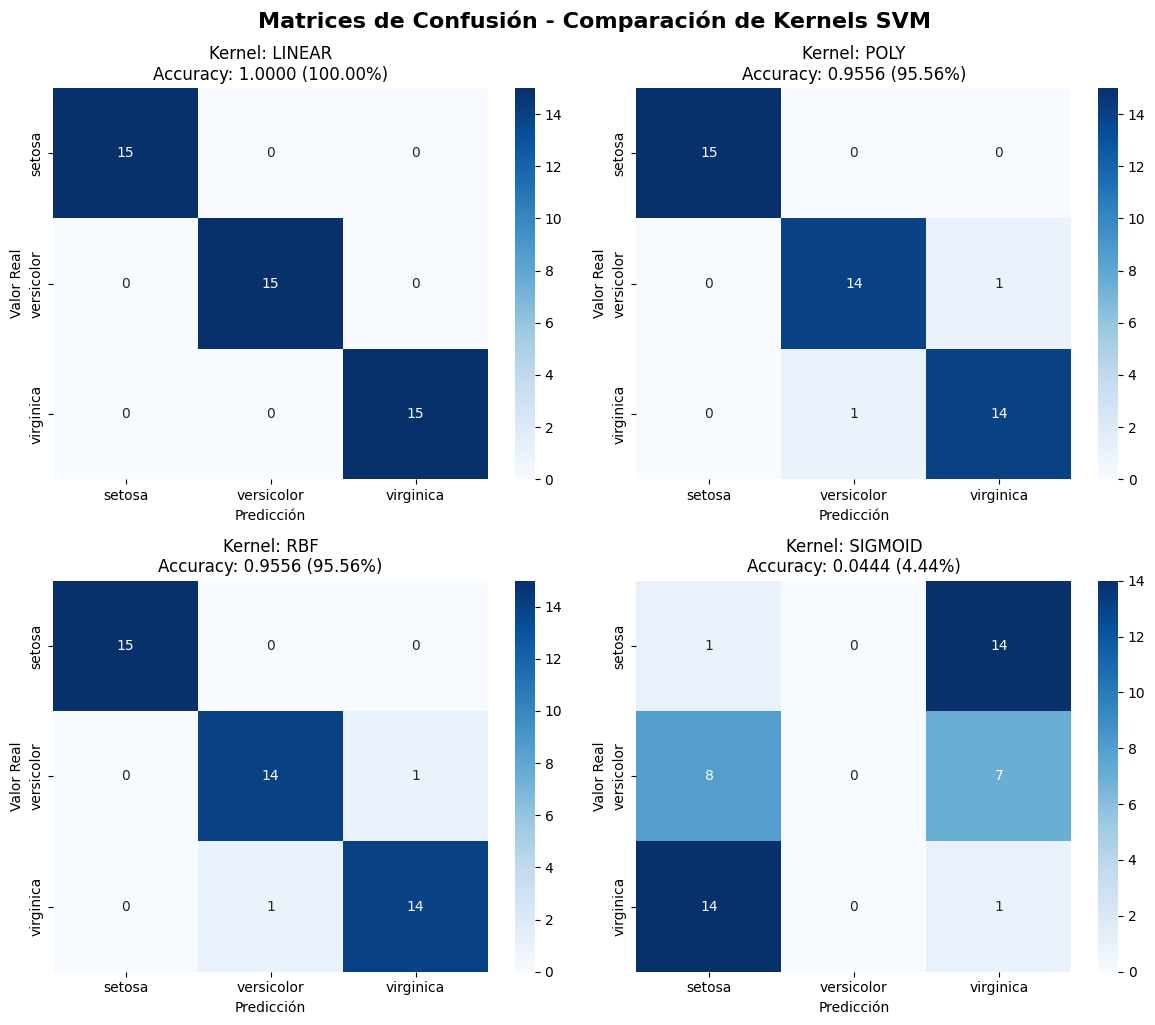

In [6]:
# Visualizar matrices de confusión para todos los kernels
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, kernel in enumerate(kernels):
    cm = confusion_matrix(y_test, results[kernel]['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=iris.target_names, 
                yticklabels=iris.target_names,
                ax=axes[i])
    
    accuracy = results[kernel]['accuracy']
    axes[i].set_title(f'Kernel: {kernel.upper()}\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Valor Real')

plt.tight_layout()
plt.suptitle('Matrices de Confusión - Comparación de Kernels SVM', y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [7]:
# Mostrar reportes de clasificación detallados para cada kernel
print("📋 REPORTES DE CLASIFICACIÓN DETALLADOS")
print("=" * 60)

for kernel in kernels:
    print(f"\n🔍 KERNEL: {kernel.upper()}")
    print("-" * 30)
    
    # Generar reporte de clasificación
    report = classification_report(y_test, results[kernel]['predictions'], 
                                 target_names=iris.target_names,
                                 digits=4)
    print(report)
    
    # Mostrar matriz de confusión en formato texto
    cm = confusion_matrix(y_test, results[kernel]['predictions'])
    print("Matriz de Confusión:")
    cm_df = pd.DataFrame(cm, 
                        columns=[f'Pred_{name}' for name in iris.target_names],
                        index=[f'Real_{name}' for name in iris.target_names])
    print(cm_df)
    
    print("=" * 60)

📋 REPORTES DE CLASIFICACIÓN DETALLADOS

🔍 KERNEL: LINEAR
------------------------------
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        15
  versicolor     1.0000    1.0000    1.0000        15
   virginica     1.0000    1.0000    1.0000        15

    accuracy                         1.0000        45
   macro avg     1.0000    1.0000    1.0000        45
weighted avg     1.0000    1.0000    1.0000        45

Matriz de Confusión:
                 Pred_setosa  Pred_versicolor  Pred_virginica
Real_setosa               15                0               0
Real_versicolor            0               15               0
Real_virginica             0                0              15

🔍 KERNEL: POLY
------------------------------
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        15
  versicolor     0.9333    0.9333    0.9333        15
   virginica     0.9333    0.9333    0.9333        1

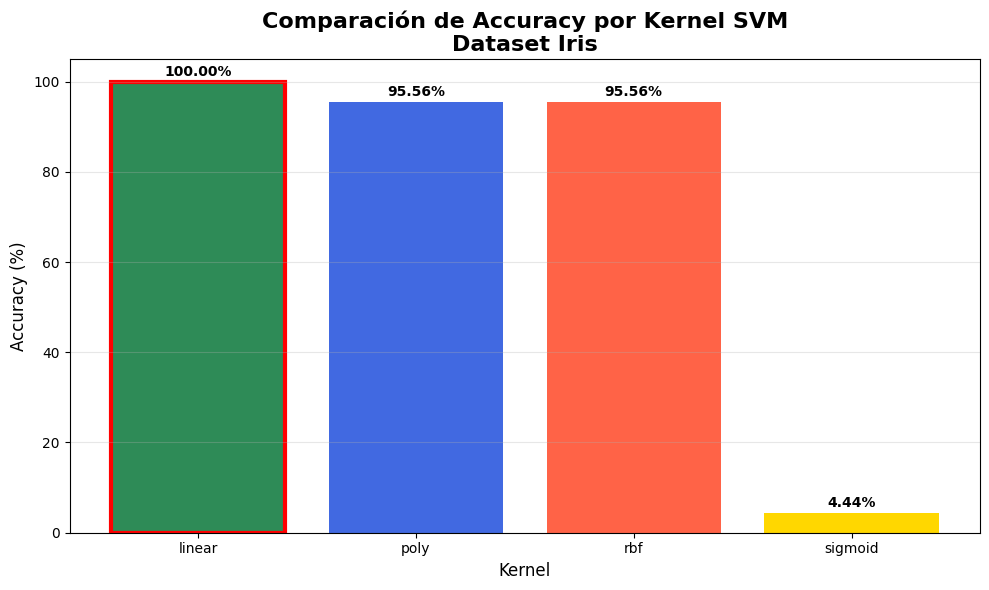

In [9]:
# Crear gráfico de barras comparativo de accuracies
plt.figure(figsize=(10, 6))

colors = ['#2E8B57', '#4169E1', '#FF6347', '#FFD700']
bars = plt.bar(accuracy_df['Kernel'], accuracy_df['Accuracy_Percentage'], color=colors)

# Añadir valores en las barras
for bar, accuracy in zip(bars, accuracy_df['Accuracy_Percentage']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{accuracy:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Comparación de Accuracy por Kernel SVM\nDataset Iris', fontsize=16, fontweight='bold')
plt.xlabel('Kernel', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)

# Resaltar el mejor kernel
best_idx = accuracy_df['Accuracy_Percentage'].idxmax()
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.show()

## Análisis de Resultados

### Interpretación de los Kernels:

1. **Kernel Lineal**: Busca un hiperplano lineal para separar las clases. Funciona bien cuando los datos son linealmente separables.

2. **Kernel Polinomial (poly)**: Crea transformaciones polinomiales de los datos, permitiendo fronteras de decisión no lineales de forma polinomial.

3. **Kernel RBF (Radial Basis Function)**: También conocido como kernel Gaussiano, es muy flexible y puede crear fronteras de decisión complejas y no lineales.

4. **Kernel Sigmoidal**: Basado en funciones hiperbólicas tangentes, similar a redes neuronales.

### Conclusiones:

- El dataset Iris es relativamente simple y las clases están bien separadas
- Los kernels **RBF** y **lineal** típicamente performan mejor en este dataset
- El kernel **sigmoidal** puede tener problemas de estabilidad con ciertos parámetros
- La elección del kernel depende de la naturaleza de los datos y la complejidad de las fronteras de decisión necesarias